In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time

In [2]:
# Load data
data = np.loadtxt('../data/MLoGPU_data3_train.csv', delimiter=',')
X = data[:, :-1]
y = data[:, -1]

# Take all classes
classes = np.unique(y)
classes = classes.astype(int).tolist()

In [3]:
# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3000, 7) (1000, 7) (3000,) (1000,)


In [4]:
# Data normalization
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)

X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

In [5]:
# No train needed for kNN

In [6]:
# Compute distance of test point to all train points
def compute_distances(X_train, y_train, X_test_point):
    distances = []
    for i in range(len(X_train)):
        # Euclidean distance
        dist = np.sqrt(np.sum((np.array(X_train[i]) - np.array(X_test_point))**2))
        distances.append((dist, y_train[i]))
       
    # Sort by closest samples
    distances.sort(key=lambda x: x[0])
    return distances

In [7]:
start_time = time.time()

# Collect all test distances
dists = []
for i in range(len(X_test_norm)):
    dists.append(compute_distances(X_train_norm, y_train, X_test_norm[i]))
    
dists = np.array(dists)
print(dists, dists.shape)

# Execution time for computing distances
dists_time = time.time() - start_time
print(f'Execution time for calculationg distances: {dists_time:.2f}s')

[[[ 0.22375433  3.        ]
  [ 0.44171007  3.        ]
  [ 0.5688378   4.        ]
  ...
  [10.39534096  4.        ]
  [11.11104684  3.        ]
  [15.48335366  2.        ]]

 [[ 0.76367396  4.        ]
  [ 0.99951275  4.        ]
  [ 1.09239722  2.        ]
  ...
  [11.44623805  4.        ]
  [12.02045783  3.        ]
  [16.52614528  2.        ]]

 [[ 0.38028715  4.        ]
  [ 0.53881606  3.        ]
  [ 0.56276894  4.        ]
  ...
  [11.49312098  4.        ]
  [12.27149069  3.        ]
  [16.7533589   2.        ]]

 ...

 [[ 0.48608771  4.        ]
  [ 0.49058432  4.        ]
  [ 0.50998628  5.        ]
  ...
  [10.98575457  4.        ]
  [11.8033961   3.        ]
  [16.22286192  2.        ]]

 [[ 0.52946019  5.        ]
  [ 0.60833565  3.        ]
  [ 0.61657062  4.        ]
  ...
  [11.11573205  3.        ]
  [11.33652109  4.        ]
  [15.58041977  2.        ]]

 [[ 1.26382494  4.        ]
  [ 1.32396519  3.        ]
  [ 1.39107289  4.        ]
  ...
  [12.0536305   4.      

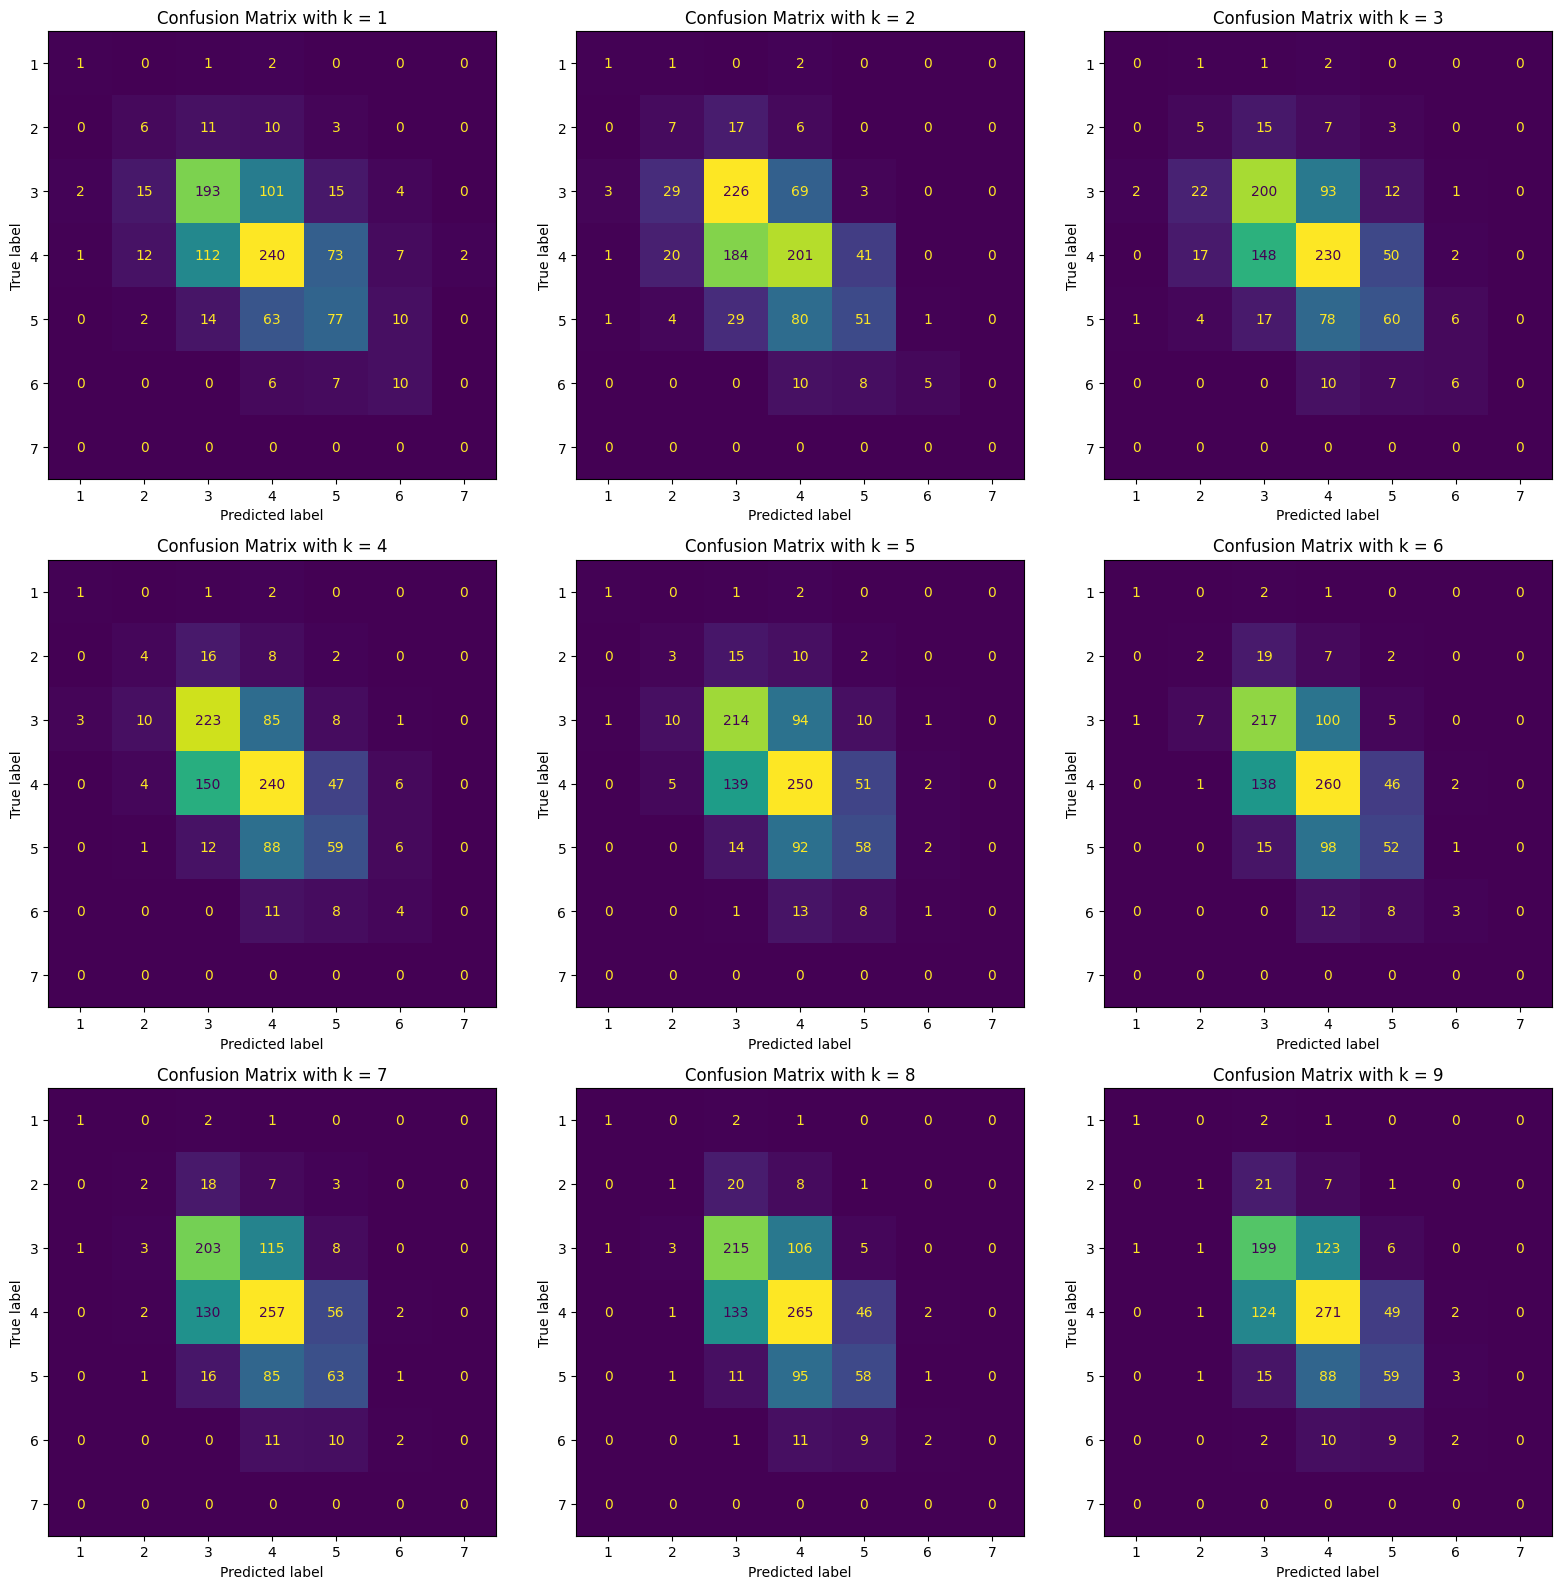

In [8]:
preds = np.zeros_like(y_test)
accuracies = []
exec_times = []
k_values = range(1, 10)

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
axs = axs.ravel()

for K_VALUE in k_values:
    ax = axs[K_VALUE - 1]
    
    start_time = time.time()
    
    # Take nearest k train samples' labels for each test sample
    nearest_labels = dists[:, :K_VALUE, 1]
    
    # Compute mode for each test sample
    preds_res = stats.mode(nearest_labels, keepdims=True, axis=1)
    preds = np.array(preds_res)[0, ...]
    
    exec_times.append(time.time() - start_time)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, preds, labels=classes)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix with k = {K_VALUE}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    
    accuracies.append(np.sum(np.trace(cm)) / len(preds) * 100)
    
plt.tight_layout()
plt.show()

In [9]:
# Average total execution time of kNN
total_exec_times = [t + dists_time for t in exec_times]
print(f"Execution time on CPU: {np.mean(total_exec_times):.6f} " + u"\u00B1" + f" {np.std(total_exec_times):.6f} s")

Execution time on CPU: 48.525764 ± 0.000678 s


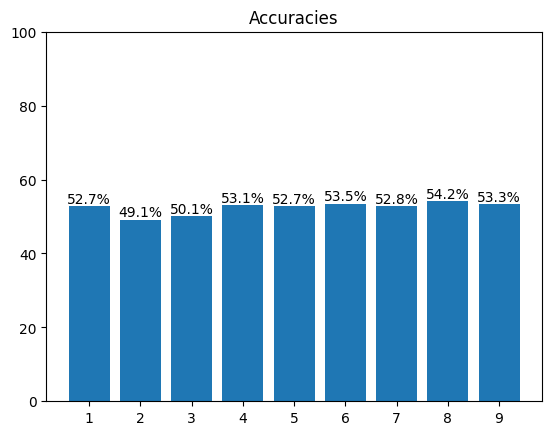

In [10]:
# Accuracies
accuracies_str = [f"{acc:.1f}%" for acc in accuracies]
fig, ax = plt.subplots()
bars = ax.bar(k_values, accuracies)
ax.bar_label(bars, labels=accuracies_str)
plt.title('Accuracies')
plt.xticks(k_values)
_, _ = plt.ylim((0,100))